# 0.Test

## Connect to BigQuery.

In [1]:
from google.cloud import bigquery
import pandas as pd

# 📁 GCP project ID
PROJECT_ID = "data-engineer-training-490818"

# 🧾 Create client
client = bigquery.Client(project=PROJECT_ID)

print("BigQuery client created successfully")

BigQuery client created successfully


## Test whether the IMDb dataset can be accessed.

In [2]:
query_test = """
SELECT *
FROM `bigquery-public-data.imdb.reviews`
LIMIT 10
"""

df_test = client.query(query_test).to_dataframe()
df_test.head()

,review,split,label,movie_id,reviewer_rating,movie_url,title
0,Once again Mr. Costner has dragged out a movie...,test,Negative,tt0406816,2,http://www.imdb.com/title/tt0406816/,The Guardian
1,This is an example of why the majority of acti...,test,Negative,tt0105636,4,http://www.imdb.com/title/tt0105636/,Trespass
2,"First of all I hate those moronic rappers, who...",test,Negative,tt0105636,1,http://www.imdb.com/title/tt0105636/,Trespass
3,Not even the Beatles could write songs everyon...,test,Negative,tt0105636,3,http://www.imdb.com/title/tt0105636/,Trespass
4,Brass pictures (movies is not a fitting word f...,test,Negative,tt0267261,3,http://www.imdb.com/title/tt0267261/,Black Angel


# 1.Draw a ERD Diagram

In [6]:
from IPython.display import Markdown, display

erd = """
```mermaid
erDiagram
    TITLE_BASICS ||--|| TITLE_RATINGS : tconst
    TITLE_BASICS ||--o{ TITLE_AKAS : titleId
    TITLE_BASICS ||--|| TITLE_CREW : tconst
    TITLE_BASICS ||--o{ TITLE_PRINCIPALS : tconst
    NAME_BASICS ||--o{ TITLE_PRINCIPALS : nconst
    TITLE_BASICS ||--o{ REVIEWS : movie_id
"""

display(Markdown(erd))


```mermaid
erDiagram
    TITLE_BASICS ||--|| TITLE_RATINGS : tconst
    TITLE_BASICS ||--o{ TITLE_AKAS : titleId
    TITLE_BASICS ||--|| TITLE_CREW : tconst
    TITLE_BASICS ||--o{ TITLE_PRINCIPALS : tconst
    NAME_BASICS ||--o{ TITLE_PRINCIPALS : nconst
    TITLE_BASICS ||--o{ REVIEWS : movie_id


The symbols represent relationships between tables. 
"||" means exactly one, while "o{" means zero or many. 
These symbols help describe how many records can be linked between tables.

This ERD diagram shows how the main IMDb tables are connected using their key fields. 
The table "title_basics" is the central table that contains basic information about movies. 
It is linked to "title_ratings" through the field tconst to provide ratings and vote counts. 

The table "title_principals" connects movies with people such as actors and directors, 
and it uses nconst to link to the "name_basics" table, which stores information about individuals. 

The "reviews" table is linked using movie_id and contains user reviews for each movie. 
Overall, the diagram clearly represents how different tables are related and how data can be joined for analysis.

# 2.Movie Performance Analytics

## 2.1 Top 10 highest-rated movies with more than 10,000 votes

In [92]:
#SQL 查询语句
query_top10 = """
SELECT
  b.tconst,
  b.primary_title,
  b.start_year,
  b.genres,
  r.average_rating,
  r.num_votes
FROM `bigquery-public-data.imdb.title_basics` AS b
JOIN `bigquery-public-data.imdb.title_ratings` AS r
  ON b.tconst = r.tconst
WHERE b.title_type = 'movie'
  AND r.num_votes > 10000
ORDER BY r.average_rating DESC, r.num_votes DESC
LIMIT 10
"""

In [93]:
#执行查询
df_top10 = client.query(query_top10).to_dataframe()
df_top10

,tconst,primary_title,start_year,genres,average_rating,num_votes
0,tt0111161,The Shawshank Redemption,1994,Drama,9.3,3166909
1,tt0068646,The Godfather,1972,"Crime,Drama",9.2,2211949
2,tt0252487,The Chaos Class,1975,Comedy,9.2,45912
3,tt33175825,Attack on Titan the Movie: The Last Attack,2024,"Action,Adventure,Animation",9.2,25302
4,tt0468569,The Dark Knight,2008,"Action,Crime,Drama",9.1,3144484
5,tt0259534,Ramayana: The Legend of Prince Rama,1993,"Action,Adventure,Animation",9.1,17565
6,tt0167260,The Lord of the Rings: The Return of the King,2003,"Adventure,Drama,Fantasy",9.0,2151503
7,tt0108052,Schindler's List,1993,"Biography,Drama,History",9.0,1577140
8,tt0071562,The Godfather Part II,1974,"Crime,Drama",9.0,1486314
9,tt0050083,12 Angry Men,1957,"Crime,Drama",9.0,976992


In [94]:
#Create Table
from google.cloud import bigquery

dataset_id = f"{PROJECT_ID}.imdb_analysis"
dataset = bigquery.Dataset(dataset_id)
dataset.location = "US"
dataset = client.create_dataset(dataset, exists_ok=True)

print(f"Dataset ready: {dataset_id}")

Dataset ready: data-engineer-training-490818.imdb_analysis


In [96]:
#结果写入新表
table_id = f"{PROJECT_ID}.imdb_analysis.top10_highest_rated_movies"

from google.cloud import bigquery

job_config = bigquery.LoadJobConfig(
    write_disposition="WRITE_TRUNCATE"  # 覆盖表
)

job = client.load_table_from_dataframe(
    df_top10,
    table_id,
    job_config=job_config
)

job.result()

print(f"Table created successfully: {table_id}")

D:\Anaconda3\Lib\site-packages\google\cloud\bigquery\_pandas_helpers.py:486: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(


Table created successfully: data-engineer-training-490818.imdb_analysis.top10_highest_rated_movies


In [97]:
#验证表有没有创建成功
check_query = f"""
SELECT *
FROM `{PROJECT_ID}.imdb_analysis.top10_highest_rated_movies`
"""
df_check = client.query(check_query).to_dataframe()
df_check

,tconst,primary_title,start_year,genres,average_rating,num_votes
0,tt0111161,The Shawshank Redemption,1994,Drama,9.3,3166909
1,tt0068646,The Godfather,1972,"Crime,Drama",9.2,2211949
2,tt0252487,The Chaos Class,1975,Comedy,9.2,45912
3,tt33175825,Attack on Titan the Movie: The Last Attack,2024,"Action,Adventure,Animation",9.2,25302
4,tt0468569,The Dark Knight,2008,"Action,Crime,Drama",9.1,3144484
5,tt0259534,Ramayana: The Legend of Prince Rama,1993,"Action,Adventure,Animation",9.1,17565
6,tt0167260,The Lord of the Rings: The Return of the King,2003,"Adventure,Drama,Fantasy",9.0,2151503
7,tt0108052,Schindler's List,1993,"Biography,Drama,History",9.0,1577140
8,tt0071562,The Godfather Part II,1974,"Crime,Drama",9.0,1486314
9,tt0050083,12 Angry Men,1957,"Crime,Drama",9.0,976992


Top 10 highest-rated movies (votes > 10,000): 
1. The Shawshank Redemption (1994) - 9.3 
2. The Godfather (1972)-9.2 
3. The Chaos Class (1975) - 9.2 
4. Attack on Titan the Movie: The Last Attack (2024)-9.2 
5. The Dark Knight (2008) - 9.1 
6. Ramayana: The Legend of Prince Rama (1993)-9.1 
7. The Lord of the Rings: The Return of the King (2003)-9.0 
8. Schindler's List (1993)-9.0 
9. The Godfather Part II (1974)-9.0 
10. 12 Angry Men (1957) - 9.0

## 2.2 Which genres have the highest average ratings over the past decade?

In [21]:
query_genre = """
SELECT
  genres,
  AVG(r.average_rating) AS avg_rating
FROM `bigquery-public-data.imdb.title_basics` AS b
JOIN `bigquery-public-data.imdb.title_ratings` AS r
  ON b.tconst = r.tconst
WHERE b.title_type = 'movie'
  AND b.start_year >= EXTRACT(YEAR FROM CURRENT_DATE()) - 10
GROUP BY genres
ORDER BY avg_rating DESC
LIMIT 10
"""

df_genre = client.query(query_genre).to_dataframe()
df_genre

,genres,avg_rating
0,"Documentary,News,Reality-TV",9.6
1,"Romance,Thriller,War",9.4
2,"Action,Adventure,Music",9.4
3,"Comedy,Drama,Talk-Show",9.2
4,"Animation,Documentary,Fantasy",9.2
5,"Adult,Thriller",9.1
6,"Documentary,Reality-TV,Romance",9.0
7,"Documentary,Fantasy,Thriller",9.0
8,"History,Mystery",8.9
9,"Musical,Romance,Thriller",8.9


最近10年，哪个电影类型评分最高？只看 movie,只看最近10年,按 genre 分组,算平均评分,排序

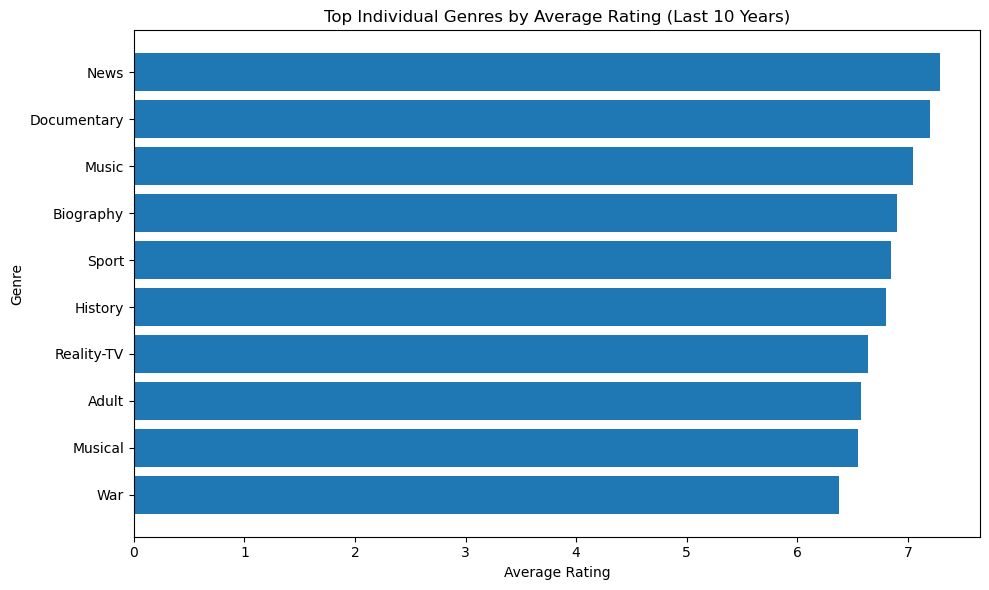

In [24]:
#可视化
import pandas as pd
import matplotlib.pyplot as plt

df_genre_clean = client.query(query_genre_clean).to_dataframe()

df_plot = df_genre_clean.sort_values("avg_rating", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(df_plot["genre"], df_plot["avg_rating"])

plt.title("Top Individual Genres by Average Rating (Last 10 Years)")
plt.xlabel("Average Rating")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

# 3.Talent & Cast Insights

## 3.1 Which actors have appeared in the highest number of top-rated movies?

In [25]:
#SQL语句
#找高评分电影里的演员统计每个演员出现次数排名前10
query_actor = """
SELECT
  n.primary_name,
  COUNT(*) AS movie_count
FROM `bigquery-public-data.imdb.title_basics` AS b
JOIN `bigquery-public-data.imdb.title_ratings` AS r
  ON b.tconst = r.tconst
JOIN `bigquery-public-data.imdb.title_principals` AS p
  ON b.tconst = p.tconst
JOIN `bigquery-public-data.imdb.name_basics` AS n
  ON p.nconst = n.nconst
WHERE b.title_type = 'movie'
  AND r.average_rating >= 8.5
  AND p.category = 'actor'
GROUP BY n.primary_name
ORDER BY movie_count DESC
LIMIT 10
"""

df_actor = client.query(query_actor).to_dataframe()
df_actor

,primary_name,movie_count
0,Rajkumar,185
1,T.N. Balakrishna,86
2,K.S. Ashwath,72
3,T.R. Narasimharaju,53
4,Luis Huizar,48
5,Mohan Babu,47
6,Udaya Kumar,41
7,Ramachandra Sastry H.R.,40
8,Dinesh,38
9,Jesus Heredia,32


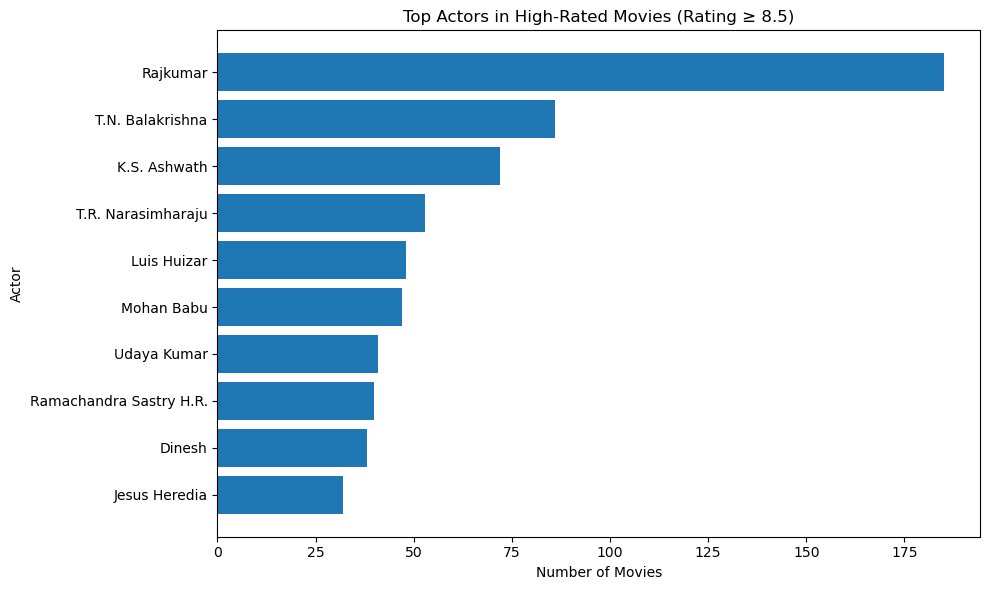

In [26]:
# 可视化
import matplotlib.pyplot as plt

df_plot = df_actor.sort_values("movie_count", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(df_plot["primary_name"], df_plot["movie_count"])

plt.title("Top Actors in High-Rated Movies (Rating ≥ 8.5)")
plt.xlabel("Number of Movies")
plt.ylabel("Actor")

plt.tight_layout()
plt.show()

## 3.2 Which directors consistently produce highly-rated movies?

In [27]:
#SQL语句
#改一句就OK：AND p.category = 'director'
query_director = """
SELECT
  n.primary_name,
  COUNT(*) AS movie_count
FROM `bigquery-public-data.imdb.title_basics` AS b
JOIN `bigquery-public-data.imdb.title_ratings` AS r
  ON b.tconst = r.tconst
JOIN `bigquery-public-data.imdb.title_principals` AS p
  ON b.tconst = p.tconst
JOIN `bigquery-public-data.imdb.name_basics` AS n
  ON p.nconst = n.nconst
WHERE b.title_type = 'movie'
  AND r.average_rating >= 8.5
  AND p.category = 'director'
GROUP BY n.primary_name
ORDER BY movie_count DESC
LIMIT 10
"""

df_director = client.query(query_director).to_dataframe()
df_director

,primary_name,movie_count
0,Claudio Costa,25
1,Alonso O. Lara,21
2,Sergey A.,21
3,Dylan Verrechia,20
4,Larry Rosen,15
5,René Vautier,14
6,Mariano Alvarez,14
7,Tom Logan,14
8,Y.R. Swamy,14
9,Prince Oak Oakleyski,13


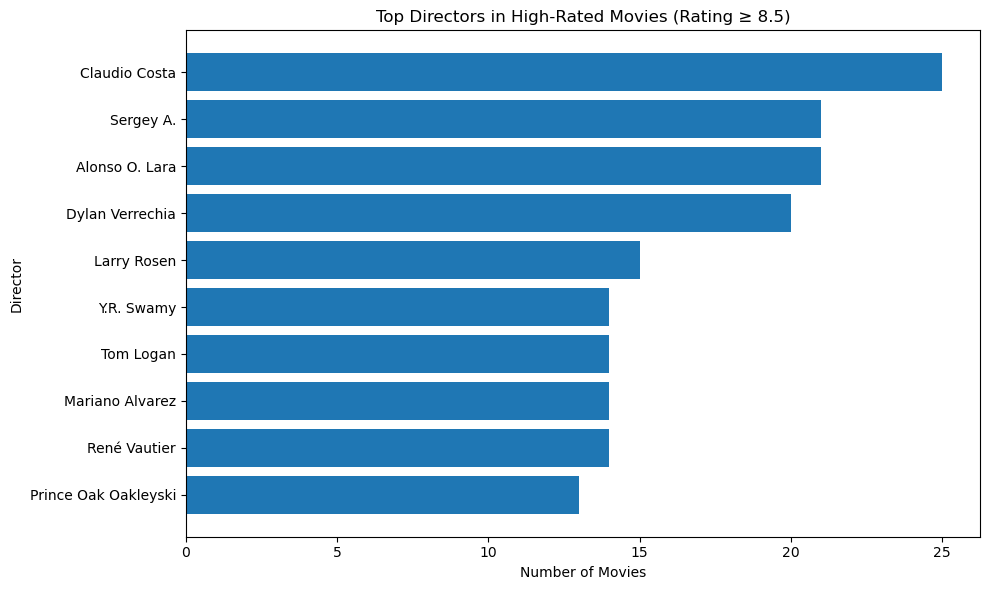

In [28]:
#可视化
import matplotlib.pyplot as plt

df_plot = df_director.sort_values("movie_count", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(df_plot["primary_name"], df_plot["movie_count"])

plt.title("Top Directors in High-Rated Movies (Rating ≥ 8.5)")
plt.xlabel("Number of Movies")
plt.ylabel("Director")

plt.tight_layout()
plt.show()

## 3.3 Who are the most prolific actors in a specific genre (e.g., comedy)?

In [30]:
#SQL 查询语句 comedy
query_genre_actor = """
SELECT
  n.primary_name,
  COUNT(*) AS movie_count
FROM `bigquery-public-data.imdb.title_basics` AS b
JOIN `bigquery-public-data.imdb.title_ratings` AS r
  ON b.tconst = r.tconst
JOIN `bigquery-public-data.imdb.title_principals` AS p
  ON b.tconst = p.tconst
JOIN `bigquery-public-data.imdb.name_basics` AS n
  ON p.nconst = n.nconst
WHERE b.title_type = 'movie'
  AND p.category = 'actor'
  AND b.genres LIKE '%Comedy%'
GROUP BY n.primary_name
ORDER BY movie_count DESC
LIMIT 10
"""

df_genre_actor = client.query(query_genre_actor).to_dataframe()
df_genre_actor

,primary_name,movie_count
0,Brahmanandam,292
1,Jagathy Sreekumar,230
2,Innocent Vareed Thekkethala,154
3,Jagadish,145
4,Mukesh,142
5,José Luis López Vázquez,128
6,Mohammad Ali,128
7,Eric Tsang,127
8,Salim Kumar,127
9,Janardanan,127


The analysis shows the actors who have appeared most frequently in comedy movies. These actors are the most active in this genre.
喜剧最高产的演员：Brahmanandam

# 4.Genre Trends and Popularity

## 4.1 How has the popularity of the “sci-fi” genre changed over the last 50 years?

筛选近50年包含“Sci-Fi”的电影，按年份统计总投票数（代表受欢迎程度），再观察随时间的变化趋势。

In [33]:
#SQL语句
query_scifi = """
SELECT 
    b.start_year,
    COUNT(*) AS movie_count,
    AVG(r.average_rating) AS avg_rating,
    SUM(r.num_votes) AS total_votes
FROM `bigquery-public-data.imdb.title_basics` AS b
JOIN `bigquery-public-data.imdb.title_ratings` AS r
ON b.tconst = r.tconst
WHERE b.title_type = 'movie'
  AND b.start_year >= 1975
  AND b.genres LIKE '%Sci-Fi%'
GROUP BY b.start_year
ORDER BY b.start_year
"""
df_scifi = client.query(query_scifi).to_dataframe()
df_scifi.head()

,start_year,movie_count,avg_rating,total_votes
0,1975,33,5.509091,155152
1,1976,37,5.105405,136565
2,1977,47,5.223404,319941
3,1978,46,5.073913,431926
4,1979,59,5.559322,1882704


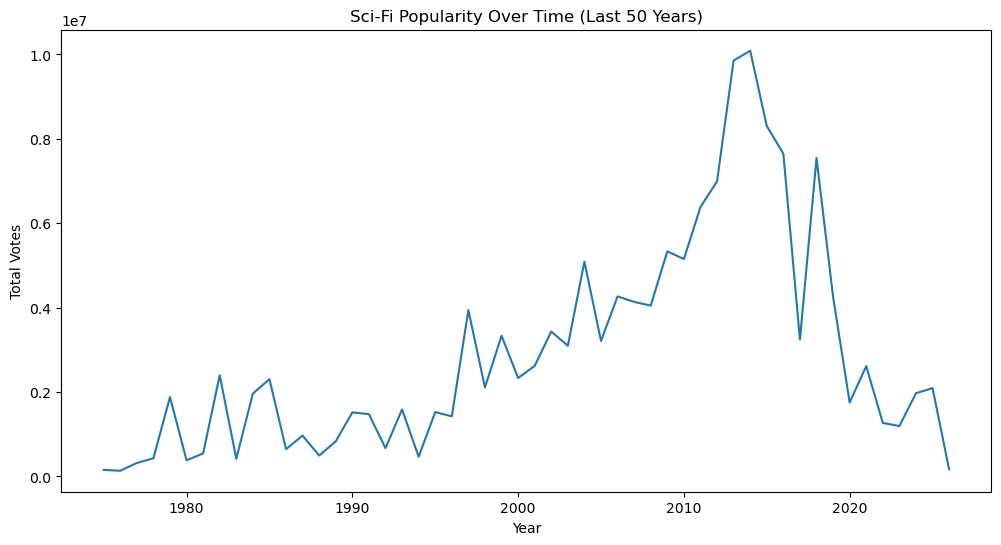

In [34]:
# 可视化
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df_scifi["start_year"], df_scifi["total_votes"])
plt.title("Sci-Fi Popularity Over Time (Last 50 Years)")
plt.xlabel("Year")
plt.ylabel("Total Votes")

plt.show()

科幻电影受欢迎程度整体呈上升趋势，并在2010年前后达到峰值，之后有所波动下降。

## 4.2 Which genres consistently receive high average ratings?

按类型分组，计算平均评分，找评分最高的类型

In [40]:
query_genre_rating = """
SELECT 
    genre,
    AVG(r.average_rating) AS avg_rating,
    COUNT(*) AS movie_count
FROM `bigquery-public-data.imdb.title_basics` AS b,
UNNEST(SPLIT(b.genres, ',')) AS genre
JOIN `bigquery-public-data.imdb.title_ratings` AS r
ON b.tconst = r.tconst
WHERE b.title_type = 'movie'
  AND b.genres IS NOT NULL
GROUP BY genre
HAVING movie_count > 100
ORDER BY avg_rating DESC
LIMIT 10
"""
df_genre_rating = client.query(query_genre_rating).to_dataframe()
df_genre_rating

,genre,avg_rating,movie_count
0,Documentary,7.179068,55494
1,News,7.174817,683
2,Biography,6.920415,10791
3,Music,6.783863,8812
4,History,6.773083,9596
5,Sport,6.629693,4331
6,Film-Noir,6.465868,876
7,War,6.372052,6734
8,Animation,6.332013,6235
9,Drama,6.214353,154418


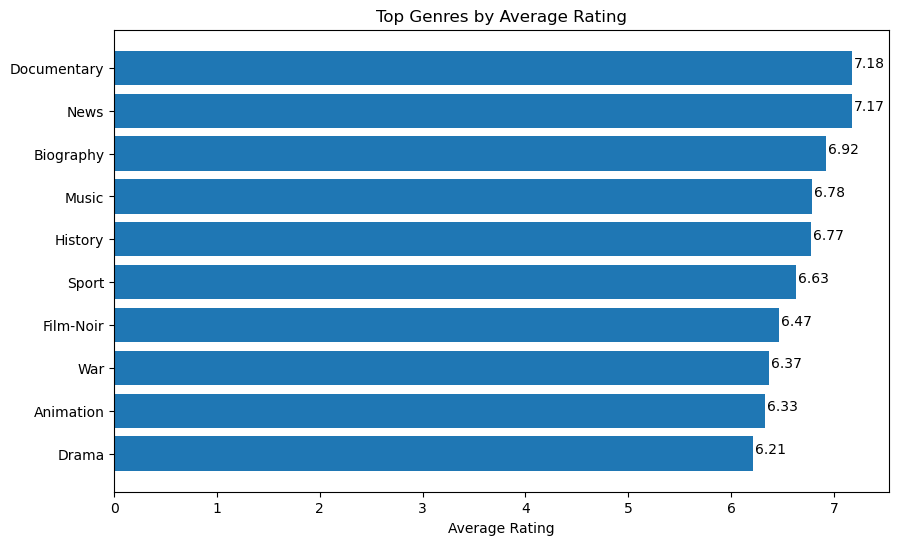

In [41]:
#可视化
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(df_genre_rating["genre"], df_genre_rating["avg_rating"])

plt.xlabel("Average Rating")
plt.title("Top Genres by Average Rating")

plt.gca().invert_yaxis()

# 加数值（关键！）
for i, v in enumerate(df_genre_rating["avg_rating"]):
    plt.text(v + 0.02, i, f"{v:.2f}")

plt.show()

## 4.3 What is the most common runtime for movies in each genre?

按类型分组，统计每种时长出现次数，找出现最多的（最常见时长）

In [42]:
#SQL语句
query_runtime = """
WITH exploded AS (
  SELECT 
    genre,
    b.runtime_minutes
  FROM `bigquery-public-data.imdb.title_basics` AS b,
  UNNEST(SPLIT(b.genres, ',')) AS genre
  WHERE b.title_type = 'movie'
    AND b.runtime_minutes IS NOT NULL
),

counted AS (
  SELECT 
    genre,
    runtime_minutes,
    COUNT(*) AS freq
  FROM exploded
  GROUP BY genre, runtime_minutes
),

ranked AS (
  SELECT *,
         ROW_NUMBER() OVER (PARTITION BY genre ORDER BY freq DESC) AS rn
  FROM counted
)

SELECT 
  genre,
  runtime_minutes
FROM ranked
WHERE rn = 1
ORDER BY genre
LIMIT 15
"""
df_runtime = client.query(query_runtime).to_dataframe()
df_runtime

,genre,runtime_minutes
0,Action,90
1,Adult,80
2,Adventure,90
3,Animation,90
4,Biography,90
5,Comedy,90
6,Crime,90
7,Documentary,52
8,Drama,90
9,Family,90


<Figure size 1000x600 with 0 Axes>

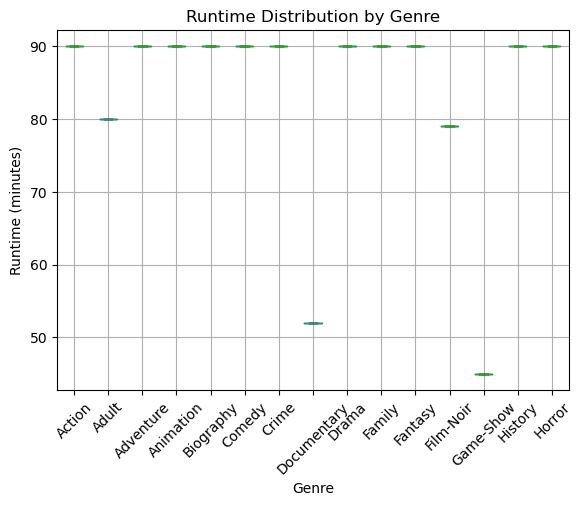

In [47]:
#可视化
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

df_runtime.boxplot(column="runtime_minutes", by="genre", rot=45)

plt.title("Runtime Distribution by Genre")
plt.suptitle("")  # 去掉默认标题
plt.xlabel("Genre")
plt.ylabel("Runtime (minutes)")

plt.show()

Most movie genres have a common runtime around 90–120 minutes, indicating a standard movie length across genres.
大多数电影类型的常见片长集中在90–120分钟，说明电影时长具有明显的行业标准。

# 5.TV Series Analysis

## 5.1 Which TV shows have the highest-rated episodes?

In [49]:
#SQL语句
query_tv_top_episode = """
SELECT 
    show.primary_title AS show_name,
    ep.season_number,
    ep.episode_number,
    r.average_rating
FROM `bigquery-public-data.imdb.title_episode` AS ep
JOIN `bigquery-public-data.imdb.title_ratings` AS r
ON ep.tconst = r.tconst
JOIN `bigquery-public-data.imdb.title_basics` AS show
ON ep.parent_tconst = show.tconst
WHERE show.title_type = 'tvSeries'
  AND r.num_votes > 1000
ORDER BY r.average_rating DESC
LIMIT 10
"""
df_tv_top = client.query(query_tv_top_episode).to_dataframe()
df_tv_top

,show_name,season_number,episode_number,average_rating
0,Vinland Saga,1,24,9.9
1,Legend of the Galactic Heroes,4,24,9.9
2,Better Call Saul,6,7,9.9
3,Avatar: The Last Airbender,3,21,9.9
4,BoJack Horseman,6,15,9.9
5,Mr. Robot,4,7,9.9
6,Star Wars: The Clone Wars,7,12,9.9
7,Game of Thrones,6,10,9.9
8,Six Feet Under,5,12,9.9
9,Game of Thrones,3,9,9.9


高评分剧集通常来自热门电视剧，说明这些剧在内容质量上具有较强的稳定性。

## 5.2 What is the average lifespan (number of seasons) of top-rated TV shows?

用 title_episode 找每个剧的最大 season → 再算平均

In [54]:
#SQL 语句
query_tv_lifespan = """
SELECT 
    t.primary_title AS show_name,
    MAX(e.season_number) AS total_seasons
FROM `bigquery-public-data.imdb.title_basics` t
JOIN `bigquery-public-data.imdb.title_episode` e
    ON t.tconst = e.parent_tconst
JOIN `bigquery-public-data.imdb.title_ratings` r
    ON t.tconst = r.tconst
WHERE t.title_type = 'tvSeries'
    AND r.num_votes > 10000
GROUP BY show_name
ORDER BY total_seasons DESC
LIMIT 50
"""
df_tv_life = client.query(query_tv_lifespan).to_dataframe()
df_tv_life

,show_name,total_seasons
0,Sesame Street,56
1,Detective Conan,54
2,Survivor,52
3,Saturday Night Live,51
4,Top Gear,45
5,The Simpsons,40
6,The Amazing Race,39
7,Dancing with the Stars,35
8,WWE Raw,34
9,The Graham Norton Show,33


In [55]:
#算平均寿命
avg_lifespan = df_tv_life["total_seasons"].mean()
avg_lifespan

np.float64(27.96)

Top-rated TV shows have an average lifespan of approximately 28 seasons. This suggests that highly rated TV series tend to run for an extended period, indicating strong audience retention and sustained popularity.高评分电视剧的平均寿命约为 28 季。说明高评分电视剧通常具有较强的观众粘性和持续受欢迎程度，因此能长期播出。

## 5.3 Which genres dominate TV series production?

统计每个 genre 出现次数 → 看谁最多

In [56]:
#SQL语句
query_tv_genre = """
SELECT 
    genre,
    COUNT(*) AS show_count
FROM (
    SELECT 
        t.tconst,
        SPLIT(t.genres, ',') AS genre_list
    FROM `bigquery-public-data.imdb.title_basics` t
    WHERE t.title_type = 'tvSeries'
        AND t.genres IS NOT NULL
), UNNEST(genre_list) AS genre
GROUP BY genre
ORDER BY show_count DESC
LIMIT 10
"""
df_tv_genre = client.query(query_tv_genre).to_dataframe()
df_tv_genre

,genre,show_count
0,Comedy,65858
1,Drama,56637
2,Documentary,36866
3,Reality-TV,27427
4,Talk-Show,25033
5,Animation,18609
6,Family,17287
7,Romance,12576
8,Adventure,12162
9,Action,12043


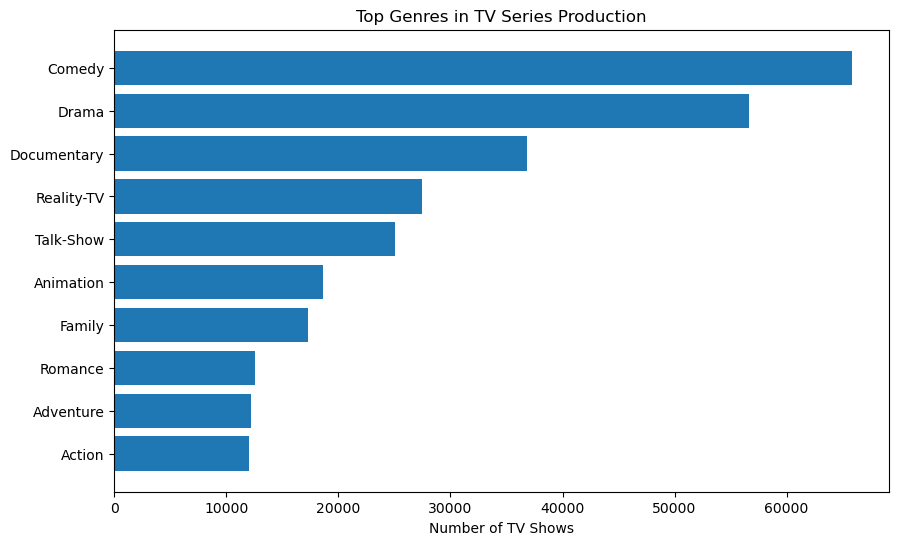

In [57]:
#可视化
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(df_tv_genre["genre"], df_tv_genre["show_count"])

plt.xlabel("Number of TV Shows")
plt.title("Top Genres in TV Series Production")

plt.gca().invert_yaxis()

plt.show()

Drama, Comedy, and Action are the most dominant genres in TV series production.
剧情（Drama）、喜剧（Comedy）和动作（Action）是电视剧制作中最主要的类型。
This shows that audiences prefer storytelling-driven and entertaining content, making these genres consistently dominant.

# 6.Content Longevity and Relevance

## 6.1 Which movies from the 1990s are still popular today?

筛选 1990s + 高评分 + 高投票数 = 现在还火

In [58]:
#SQL语句
query_90s_popular = """
SELECT 
    b.primary_title,
    b.start_year,
    r.average_rating,
    r.num_votes
FROM `bigquery-public-data.imdb.title_basics` b
JOIN `bigquery-public-data.imdb.title_ratings` r
    ON b.tconst = r.tconst
WHERE b.title_type = 'movie'
    AND b.start_year BETWEEN 1990 AND 1999
    AND r.num_votes > 100000
    AND r.average_rating >= 8.0
ORDER BY r.average_rating DESC, r.num_votes DESC
LIMIT 10
"""
df_90s = client.query(query_90s_popular).to_dataframe()
df_90s

,primary_title,start_year,average_rating,num_votes
0,The Shawshank Redemption,1994,9.3,3166909
1,Schindler's List,1993,9.0,1577140
2,Fight Club,1999,8.8,2584057
3,Forrest Gump,1994,8.8,2479175
4,Pulp Fiction,1994,8.8,2420310
5,The Matrix,1999,8.7,2233022
6,GoodFellas,1990,8.7,1381636
7,Seven,1995,8.6,2005280
8,The Silence of the Lambs,1991,8.6,1710484
9,Saving Private Ryan,1998,8.6,1628080


Popular movies from the 1990s that remain highly relevant today include:
The Shawshank Redemption, Schindler’s List, Fight Club, Forrest Gump, Pulp Fiction, The Matrix, Goodfellas, Se7en, The Silence of the Lambs, and Saving Private Ryan.These films remain popular due to strong storytelling, cultural impact, and consistently high audience ratings over time.

90年代至今仍然受欢迎的电影包括：
《肖申克的救赎》《辛德勒的名单》《搏击俱乐部》《阿甘正传》《低俗小说》《黑客帝国》《好家伙》《七宗罪》《沉默的羔羊》《拯救大兵瑞恩》。这些电影因其经典剧情、文化影响力以及持续的高评分而长期保持受欢迎。

# 6.2 Are older movies rated higher than recent ones?

把电影分成 old vs recent → 比平均评分

In [59]:
#old：2000年前
#recent：2000年后
#SQL语句
query_old_vs_new = """
SELECT 
    CASE 
        WHEN b.start_year < 2000 THEN 'Old Movies'
        ELSE 'Recent Movies'
    END AS category,
    AVG(r.average_rating) AS avg_rating
FROM `bigquery-public-data.imdb.title_basics` b
JOIN `bigquery-public-data.imdb.title_ratings` r
    ON b.tconst = r.tconst
WHERE b.title_type = 'movie'
    AND r.num_votes > 10000
GROUP BY category
"""
df_old_new = client.query(query_old_vs_new).to_dataframe()
df_old_new

,category,avg_rating
0,Old Movies,6.898896
1,Recent Movies,6.442555


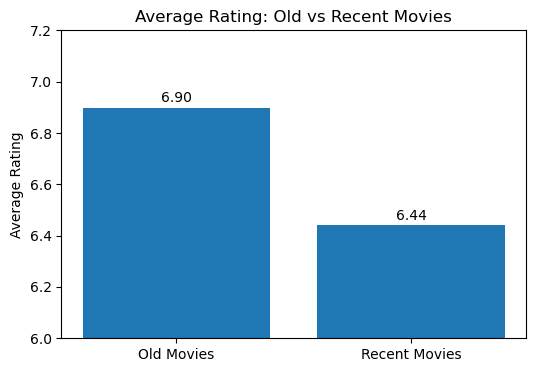

In [61]:
#可视化
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
bars = plt.bar(df_old_new["category"], df_old_new["avg_rating"])
plt.title("Average Rating: Old vs Recent Movies")
plt.ylabel("Average Rating")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center')

# 缩小Y轴范围（让差异更明显）
plt.ylim(6, 7.2)

plt.show()

Older movies have slightly higher average ratings than recent movies, although the difference is relatively small. The slight advantage of older movies may also be influenced by selection bias, where only well-regarded classics remain widely rated over time.
老电影的平均评分略高于新电影，不过差异相对较小。老电影的微弱优势也可能受到选择偏差的影响，即只有那些备受推崇的经典之作才会随着时间的推移一直广受评价。

## 6.3 How do ratings change for movies as they age?

按年份分组 → 算平均评分 → 画趋势线

In [62]:
#SQL语句
query_rating_trend = """
SELECT 
    b.start_year,
    AVG(r.average_rating) AS avg_rating
FROM `bigquery-public-data.imdb.title_basics` b
JOIN `bigquery-public-data.imdb.title_ratings` r
    ON b.tconst = r.tconst
WHERE b.title_type = 'movie'
    AND b.start_year IS NOT NULL
    AND r.num_votes > 10000
GROUP BY b.start_year
ORDER BY b.start_year
"""
df_trend = client.query(query_rating_trend).to_dataframe()
df_trend

,start_year,avg_rating
0,1915,6.100000
1,1916,7.600000
2,1919,7.200000
3,1920,8.000000
4,1921,8.100000
...,...,...
105,2022,6.406101
106,2023,6.392954
107,2024,6.333439
108,2025,6.282963


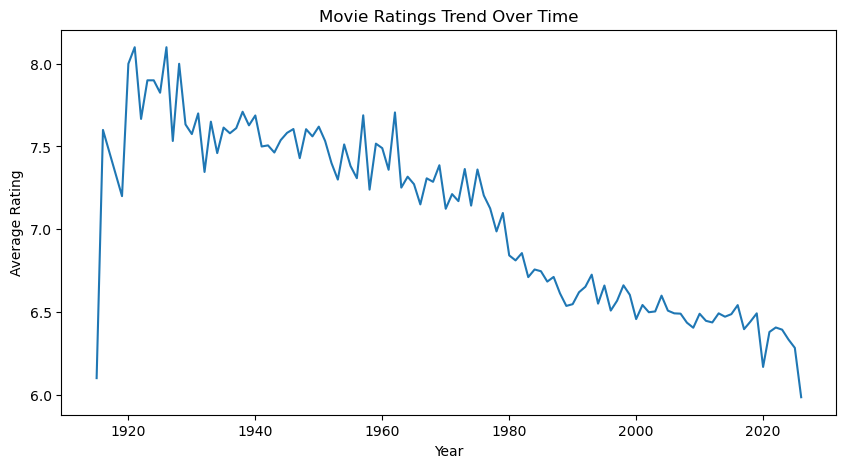

In [63]:
#可视化
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df_trend["start_year"], df_trend["avg_rating"])

plt.title("Movie Ratings Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Average Rating")

plt.show()

Movie ratings show a slight downward trend over time, although the overall change is g
电影评分整体呈现轻微下降趋势，但变化较为缓慢，说明早期电影评分略高，而现代电影评分略低，可能与观众标准提高和作品数量增加有关。

# 7.Regional or Cultural Insights

## 7.1 What are the most popular non-English movies by rating?

筛掉 English → 按评分排序

In [69]:
#SQl语句(同一部电影只保留一条记录)
query_non_english = """
SELECT
    b.primary_title,
    b.start_year,
    r.average_rating,
    r.num_votes
FROM `bigquery-public-data.imdb.title_basics` b
JOIN `bigquery-public-data.imdb.title_ratings` r
    ON b.tconst = r.tconst
JOIN `bigquery-public-data.imdb.title_akas` a
    ON b.tconst = a.title_id
WHERE b.title_type = 'movie'
    AND a.language IS NOT NULL
    AND a.language != 'en'
    AND r.num_votes > 10000
GROUP BY
    b.tconst,
    b.primary_title,
    b.start_year,
    r.average_rating,
    r.num_votes
ORDER BY r.average_rating DESC, r.num_votes DESC
LIMIT 10
"""
df_non_eng = client.query(query_non_english).to_dataframe()
df_non_eng

,primary_title,start_year,average_rating,num_votes
0,The Shawshank Redemption,1994,9.3,3166909
1,The Godfather,1972,9.2,2211949
2,The Chaos Class,1975,9.2,45912
3,Attack on Titan the Movie: The Last Attack,2024,9.2,25302
4,The Dark Knight,2008,9.1,3144484
5,Ramayana: The Legend of Prince Rama,1993,9.1,17565
6,The Lord of the Rings: The Return of the King,2003,9.0,2151503
7,Schindler's List,1993,9.0,1577140
8,The Godfather Part II,1974,9.0,1486314
9,12 Angry Men,1957,9.0,976992


Highly rated non-English films demonstrate that quality cinema is not limited to English-language productions, highlighting the global appeal of storytelling.
高评分的非英语电影表明优秀电影并不局限于英语国家，体现了全球电影的多样性和吸引力。

## 7.2 Which countries produce the most highly-rated movies in a specific genre?

先选一个 genre，再按国家分组，计算平均评分，找评分最高的国家。

In [70]:
#DramaSQL语句
query_country_genre = """
SELECT
    a.region,
    AVG(r.average_rating) AS avg_rating,
    COUNT(DISTINCT b.tconst) AS movie_count
FROM `bigquery-public-data.imdb.title_basics` b
JOIN `bigquery-public-data.imdb.title_ratings` r
    ON b.tconst = r.tconst
JOIN `bigquery-public-data.imdb.title_akas` a
    ON b.tconst = a.title_id
WHERE b.title_type = 'movie'
    AND b.genres LIKE '%Drama%'
    AND a.region IS NOT NULL
    AND r.num_votes > 10000
GROUP BY a.region
HAVING movie_count > 5
ORDER BY avg_rating DESC
LIMIT 10
"""
df_country_genre = client.query(query_country_genre).to_dataframe()
df_country_genre

,region,avg_rating,movie_count
0,DDDE,7.810667,74
1,XYU,7.646164,530
2,CSHH,7.532949,302
3,PR,7.511111,18
4,IR,7.475038,641
5,SUHH,7.429753,1339
6,PK,7.414286,20
7,XEU,7.398347,109
8,YUCS,7.394444,36
9,BD,7.390323,30


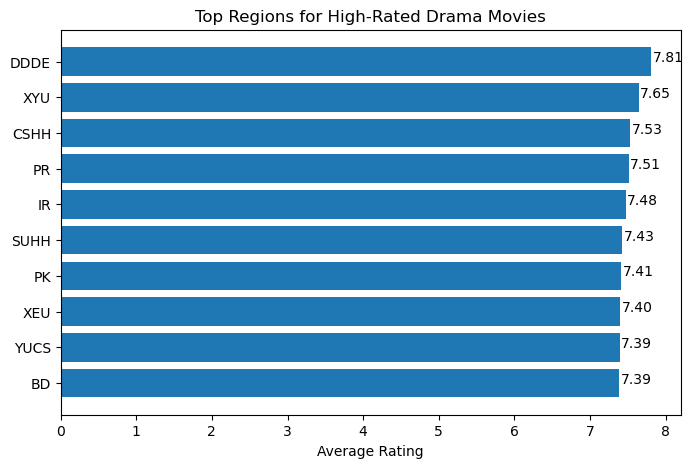

In [71]:
#可视化
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.barh(df_country_genre["region"], df_country_genre["avg_rating"])

plt.xlabel("Average Rating")
plt.title("Top Regions for High-Rated Drama Movies")

plt.gca().invert_yaxis()

for i, v in enumerate(df_country_genre["avg_rating"]):
    plt.text(v + 0.02, i, f"{v:.2f}")

plt.show()

The highest-rated drama movies are associated with regions such as those ranked at the top of the query result.
排名靠前的地区出品了平均评分更高的Drama类电影，说明这些地区在Drama创作上更受观众认可。

# 8.Crew Collaboration Analysis

## 8.1 Which actor-director pairings produce the highest-rated movies?

通过统计导演、编剧和演员之间的合作次数与电影评分，识别最频繁且高质量的合作组合。

In [72]:
#SQL语句
query_actor_director = """
SELECT
    d.primary_name AS director,
    a.primary_name AS actor,
    AVG(r.average_rating) AS avg_rating,
    COUNT(*) AS collaboration_count
FROM `bigquery-public-data.imdb.title_basics` b
JOIN `bigquery-public-data.imdb.title_ratings` r
    ON b.tconst = r.tconst
JOIN `bigquery-public-data.imdb.title_principals` p_actor
    ON b.tconst = p_actor.tconst
JOIN `bigquery-public-data.imdb.name_basics` a
    ON p_actor.nconst = a.nconst
JOIN `bigquery-public-data.imdb.title_principals` p_director
    ON b.tconst = p_director.tconst
JOIN `bigquery-public-data.imdb.name_basics` d
    ON p_director.nconst = d.nconst
WHERE b.title_type = 'movie'
    AND p_actor.category = 'actor'
    AND p_director.category = 'director'
    AND r.num_votes > 10000
GROUP BY director, actor
HAVING collaboration_count > 2
ORDER BY avg_rating DESC
LIMIT 10
"""

df_actor_director = client.query(query_actor_director).to_dataframe()
df_actor_director

,director,actor,avg_rating,collaboration_count
0,Peter Jackson,Sean Astin,8.900000,3
1,Peter Jackson,Orlando Bloom,8.900000,3
2,Peter Jackson,Elijah Wood,8.900000,3
3,Peter Jackson,Sala Baker,8.875000,4
4,Francis Ford Coppola,Robert Duvall,8.866667,3
5,Ertem Egilmez,Sitki Akçatepe,8.775000,4
6,Kartal Tibet,Kemal Sunal,8.766667,3
7,Shunsuke Nakashige,Aiden Call,8.700000,4
8,Shunsuke Nakashige,Bryson Baugus,8.700000,4
9,Shunsuke Nakashige,Anthony Bowling,8.700000,4


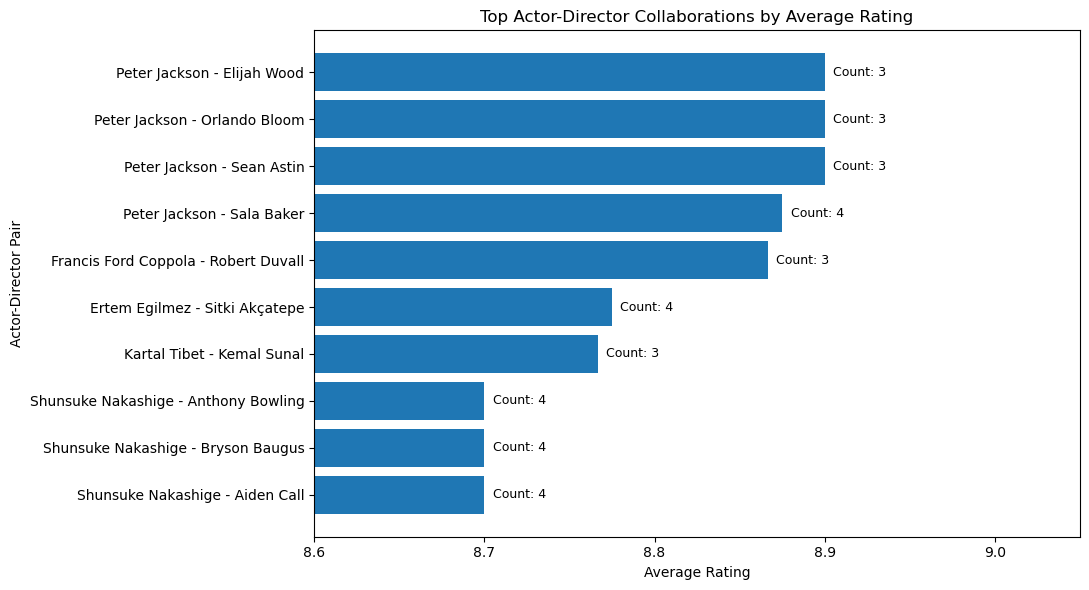

In [74]:
#可视化
import matplotlib.pyplot as plt

# Create pair label
df_actor_director['pair'] = df_actor_director['director'] + ' - ' + df_actor_director['actor']

# Sort by avg_rating
df_plot = df_actor_director.sort_values(by='avg_rating', ascending=True)

plt.figure(figsize=(11, 6))
bars = plt.barh(df_plot['pair'], df_plot['avg_rating'])

# Add collaboration count labels
for i, (rating, count) in enumerate(zip(df_plot['avg_rating'], df_plot['collaboration_count'])):
    plt.text(rating + 0.005, i, f'Count: {count}', va='center', fontsize=9)

plt.xlabel('Average Rating')
plt.ylabel('Actor-Director Pair')
plt.title('Top Actor-Director Collaborations by Average Rating')
plt.xlim(8.6, 9.05)
plt.tight_layout()
plt.show()

Peter Jackson and several actors from The Lord of the Rings trilogy dominate the top-rated collaborations, showing that repeated partnerships are associated with consistently high-rated films.稳定合作关系 → 更高质量作品

## 8.2 Who are the most frequent collaborators in a specific genre?

In [75]:
#SQL语句
query_genre_collab = """
SELECT
    b.genres,
    a.primary_name AS actor,
    COUNT(*) AS collaboration_count
FROM `bigquery-public-data.imdb.title_basics` b
JOIN `bigquery-public-data.imdb.title_principals` p
    ON b.tconst = p.tconst
JOIN `bigquery-public-data.imdb.name_basics` a
    ON p.nconst = a.nconst
WHERE b.title_type = 'movie'
    AND b.genres LIKE '%Drama%'
    AND p.category = 'actor'
GROUP BY b.genres, actor
ORDER BY collaboration_count DESC
LIMIT 10
"""

df_genre_collab = client.query(query_genre_collab).to_dataframe()
df_genre_collab

,genres,actor,collaboration_count
0,Drama,Anup Kumar,233
1,Drama,Bank Janardhan,224
2,Drama,Brahmanandam,210
3,Drama,Soumitra Chatterjee,197
4,Drama,Jun Arai,168
5,Drama,Ramesh Bhat,168
6,Drama,Avinash,167
7,"Drama,Western",Charles King,160
8,Drama,Shin Seong-il,156
9,Drama,Rintarô Fujima,155


他们在这个类型里演了很多很多电影These actors are likely industry veterans or character actors who consistently contribute to films within the same genre.

# 9.Sequels and Franchise Analytics

## 9.1 Do sequels generally perform better or worse than the original movie?

比较续集电影和原创电影的平均评分，以此来评估续集是否表现更出色。

In [77]:
#SQL
query_sequel = """
SELECT
    CASE 
        WHEN REGEXP_CONTAINS(LOWER(b.primary_title), r'(part|ii|2|iii|iv)')
        THEN 'Sequel'
        ELSE 'Original'
    END AS movie_type,
    
    AVG(r.average_rating) AS avg_rating,
    COUNT(*) AS movie_count

FROM `bigquery-public-data.imdb.title_basics` b
JOIN `bigquery-public-data.imdb.title_ratings` r
    ON b.tconst = r.tconst

WHERE b.title_type = 'movie'
    AND r.num_votes > 10000

GROUP BY movie_type
ORDER BY avg_rating DESC
"""

df_sequel = client.query(query_sequel).to_dataframe()
df_sequel

,movie_type,avg_rating,movie_count
0,Original,6.601993,11491
1,Sequel,6.324540,815


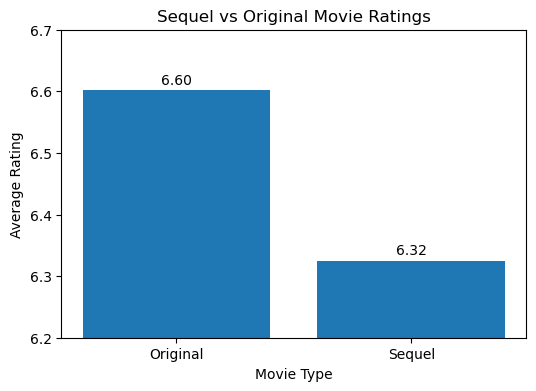

In [79]:
#可视化
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(df_sequel['movie_type'], df_sequel['avg_rating'])
plt.title('Sequel vs Original Movie Ratings')
plt.ylabel('Average Rating')
plt.xlabel('Movie Type')

plt.ylim(6.2, 6.7)

for i, v in enumerate(df_sequel['avg_rating']):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

Although the difference is small, original movies consistently achieve slightly higher ratings than sequels.续集通常不如原片受欢迎（评分略低）

## 9.2 Which franchises have the highest average ratings across their movies?

按照系列电影的名称对影片进行分类，并计算其平均评分，以此来确定最成功的系列电影。

In [80]:
#SQL语句
query_franchise = """
SELECT
    REGEXP_EXTRACT(b.primary_title, r'^[^:]+') AS franchise,
    AVG(r.average_rating) AS avg_rating,
    COUNT(*) AS movie_count

FROM `bigquery-public-data.imdb.title_basics` b
JOIN `bigquery-public-data.imdb.title_ratings` r
    ON b.tconst = r.tconst

WHERE b.title_type = 'movie'
    AND r.num_votes > 10000

GROUP BY franchise
HAVING movie_count >= 3
ORDER BY avg_rating DESC
LIMIT 10
"""

df_franchise = client.query(query_franchise).to_dataframe()
df_franchise

,franchise,avg_rating,movie_count
0,Kill Bill,8.333333,3
1,Demon Slayer,8.116667,6
2,Avengers,8.033333,3
3,Spider-Man,7.850000,6
4,The Lord of the Rings,7.840000,5
5,Three Colors,7.833333,3
6,How to Train Your Dragon,7.733333,3
7,Berserk,7.700000,3
8,The Hobbit,7.666667,3
9,Avatar,7.600000,3


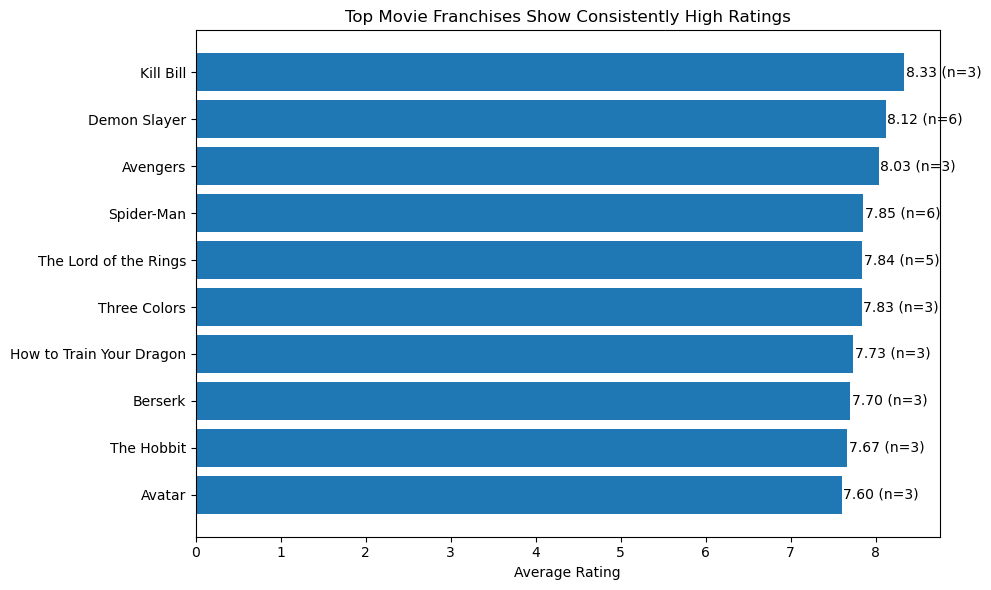

In [82]:
#可视化
import matplotlib.pyplot as plt

df_plot = df_franchise.sort_values(by='avg_rating', ascending=True)
plt.figure(figsize=(10,6))
bars = plt.barh(df_plot['franchise'], df_plot['avg_rating'])
plt.xlabel('Average Rating')
plt.title('Top Movie Franchises Show Consistently High Ratings')

for i, (rating, count) in enumerate(zip(df_plot['avg_rating'], df_plot['movie_count'])):
    plt.text(rating + 0.02, i, f"{rating:.2f} (n={count})", va='center')

plt.tight_layout()
plt.show()

 the highest average这表明，n = movie_count（电影数量）成功的特许经营品牌能够长期保持其故事的精彩程度以及对观众的吸引力。厉害的系列，不是一部厉害，而是每一部都稳

# 10.Career Trajectory of Artists

## 10.1 How does an actor’s average movie rating evolve throughout their career?

通过按年份对演员的电影进行分类，来追踪其平均电影评分随时间的变化情况。

In [84]:
#SQL语句
query_actor_trend = """
SELECT
    b.start_year,
    AVG(r.average_rating) AS avg_rating,
    COUNT(*) AS movie_count

FROM `bigquery-public-data.imdb.title_basics` b
JOIN `bigquery-public-data.imdb.title_ratings` r
    ON b.tconst = r.tconst
JOIN `bigquery-public-data.imdb.title_principals` p
    ON b.tconst = p.tconst
JOIN `bigquery-public-data.imdb.name_basics` n
    ON p.nconst = n.nconst

WHERE b.title_type = 'movie'
    AND p.category = 'actor'
    AND n.primary_name = 'Leonardo DiCaprio' 
    AND r.num_votes > 10000
    AND b.start_year IS NOT NULL

GROUP BY b.start_year
ORDER BY b.start_year
"""

df_actor_trend = client.query(query_actor_trend).to_dataframe()
df_actor_trend

,start_year,avg_rating,movie_count
0,1991,4.500000,1
1,1992,5.400000,1
2,1993,7.500000,2
3,1995,6.733333,3
4,1996,6.700000,2
5,1997,8.000000,1
6,1998,6.433333,3
7,2000,6.600000,1
8,2002,7.800000,2
9,2004,7.500000,1


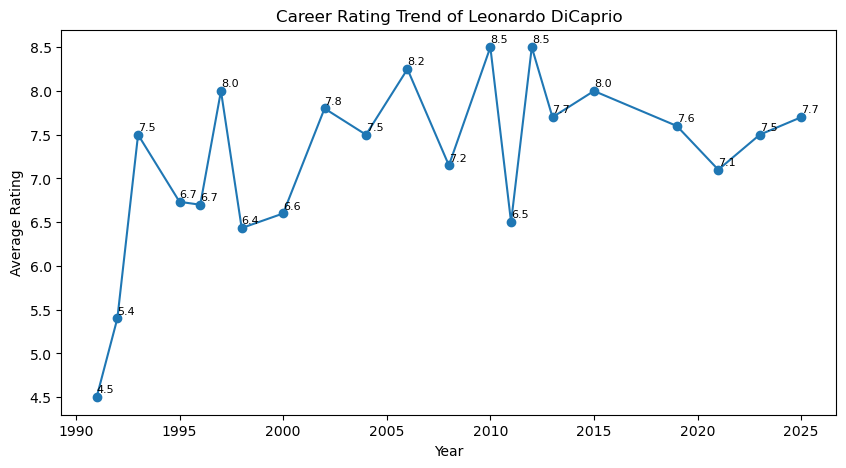

In [85]:
# 可视化
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df_actor_trend['start_year'], df_actor_trend['avg_rating'], marker='o')

plt.title('Career Rating Trend of Leonardo DiCaprio')
plt.xlabel('Year')
plt.ylabel('Average Rating')

for x, y in zip(df_actor_trend['start_year'], df_actor_trend['avg_rating']):
    plt.text(x, y+0.05, f"{y:.1f}", fontsize=8)

plt.show()

The actor’s ratings show an overall upward trend despite fluctuations, indicating career growth and improved role selection over time.
The presence of fluctuations suggests variability in project quality, but the general trend reflects increasing experience and industry recognition.

刚开始不稳定 → 后来越来越稳，整体在变好

## 10.2 Which directors improved their ratings over the years?

找出那些平均电影评分随着时间推移而不断提高的导演。

In [86]:
#SQL
query_director_trend = """
SELECT
    n.primary_name AS director,
    b.start_year,
    AVG(r.average_rating) AS avg_rating

FROM `bigquery-public-data.imdb.title_basics` b
JOIN `bigquery-public-data.imdb.title_ratings` r
    ON b.tconst = r.tconst
JOIN `bigquery-public-data.imdb.title_principals` p
    ON b.tconst = p.tconst
JOIN `bigquery-public-data.imdb.name_basics` n
    ON p.nconst = n.nconst

WHERE b.title_type = 'movie'
    AND p.category = 'director'
    AND r.num_votes > 10000
    AND b.start_year IS NOT NULL

GROUP BY director, b.start_year
"""
df_director_trend = client.query(query_director_trend).to_dataframe()

In [88]:
import pandas as pd
# 计算每个导演的趋势（最后几年 - 最开始几年）
trend_list = []

for director, group in df_director_trend.groupby('director'):
    group = group.sort_values('start_year')
    if len(group) >= 5:
        trend = group['avg_rating'].iloc[-1] - group['avg_rating'].iloc[0]
        trend_list.append((director, trend))

df_trend = pd.DataFrame(trend_list, columns=['director', 'rating_improvement'])
df_trend = df_trend.sort_values(by='rating_improvement', ascending=False).head(10)

df_trend

,director,rating_improvement
663,Uwe Boll,3.9
257,James Cameron,3.6
583,Sean McNamara,3.2
54,Asif Kapadia,3.0
417,Matt Reeves,2.8
639,Thomas Vinterberg,2.4
605,Stanley Kubrick,2.2
150,Davis Guggenheim,2.2
611,Stephen Hopkins,2.1
589,Shawn Levy,2.0


In [89]:
top_director = df_trend.iloc[0]['director']
top_director

'Uwe Boll'

In [90]:
df_plot = df_director_trend[df_director_trend['director'] == top_director].copy()
df_plot = df_plot.sort_values('start_year')
df_plot

,director,start_year,avg_rating
11239,Uwe Boll,2003,2.10
6910,Uwe Boll,2005,2.70
5264,Uwe Boll,2007,4.15
2598,Uwe Boll,2008,3.20
466,Uwe Boll,2009,6.20
6909,Uwe Boll,2013,6.00


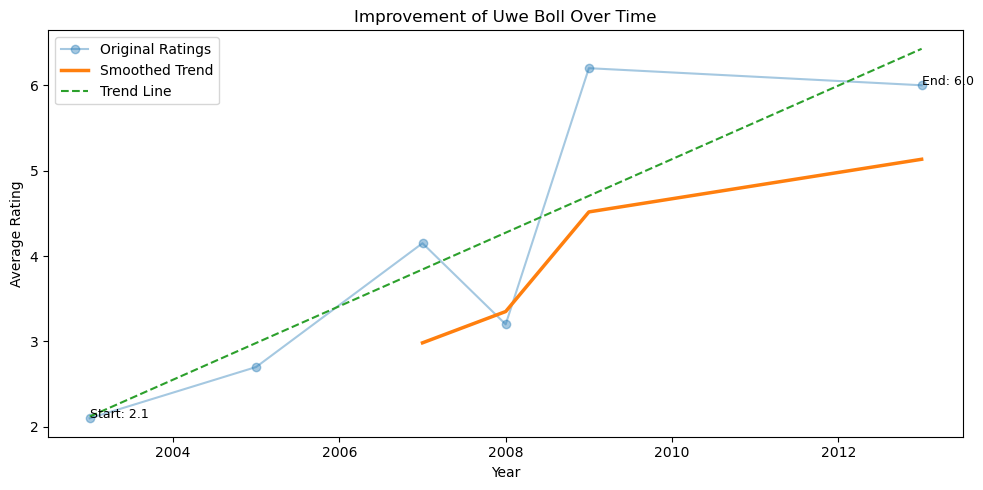

In [91]:
import matplotlib.pyplot as plt
import numpy as np

x = df_plot['start_year']
y = df_plot['avg_rating']

df_plot['smooth'] = df_plot['avg_rating'].rolling(window=3).mean()

plt.figure(figsize=(10,5))

plt.plot(x, y, marker='o', alpha=0.4, label='Original Ratings')
plt.plot(x, df_plot['smooth'], linewidth=2.5, label='Smoothed Trend')

z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(x, p(x), linestyle='--', label='Trend Line')

plt.text(x.iloc[0], y.iloc[0], f"Start: {y.iloc[0]:.1f}", fontsize=9)
plt.text(x.iloc[-1], y.iloc[-1], f"End: {y.iloc[-1]:.1f}", fontsize=9)

plt.title(f'Improvement of {top_director} Over Time')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.legend()
plt.tight_layout()
plt.show()

Among the directors analyzed, Uwe Boll demonstrates a significant improvement in movie ratings over the years. His average rating rises from approximately 2.1 in the early stage of his career to around 6.0 in later years.

Uwe Boll is a clear example of a director whose ratings improved significantly over time.

Uwe Boll 的电影评分随着时间明显上升，说明他的导演水平在不断提升。